# Lab 1: Gapminder data visualization

In [1]:
import pandas as pd
from mizani.formatters import comma_format
from plotnine import (
    aes, element_text, geom_point, geom_text, ggplot, guides, labs,
    scale_color_manual, scale_size_continuous, scale_x_continuous,
    scale_x_log10, scale_y_continuous, scale_y_log10, theme, theme_minimal
)

region_colors = {
    "africa": "#28c9dc",
    "americas": "#7ee000",
    "asia": "#ff5b75",
    "europe": "#ffe100",
}

base_theme = theme_minimal() + theme(
    figure_size=(10, 6),
    plot_title=element_text(size=16, weight="bold"),
    axis_title=element_text(size=11),
    legend_title=element_text(weight="bold"),
)



## Plot 1: income and life expectancy

The original plot uses geom_point() to create a bubble plot. Income
maps to the horizontal position on a logarithmic scale. Life expectancy
maps to the vertical position on a linear scale. World region maps to
point colour, and population maps to point size.

In [2]:
import base64
from io import StringIO
embedded_q1_csv = base64.b64decode("...").decode("utf-8")
q1 = pd.read_csv(StringIO(embedded_q1_csv))
q1_vis = q1.dropna(subset=["income", "life_exp", "population", "four_regions"]).copy()
q1_vis.shape

(191, 9)

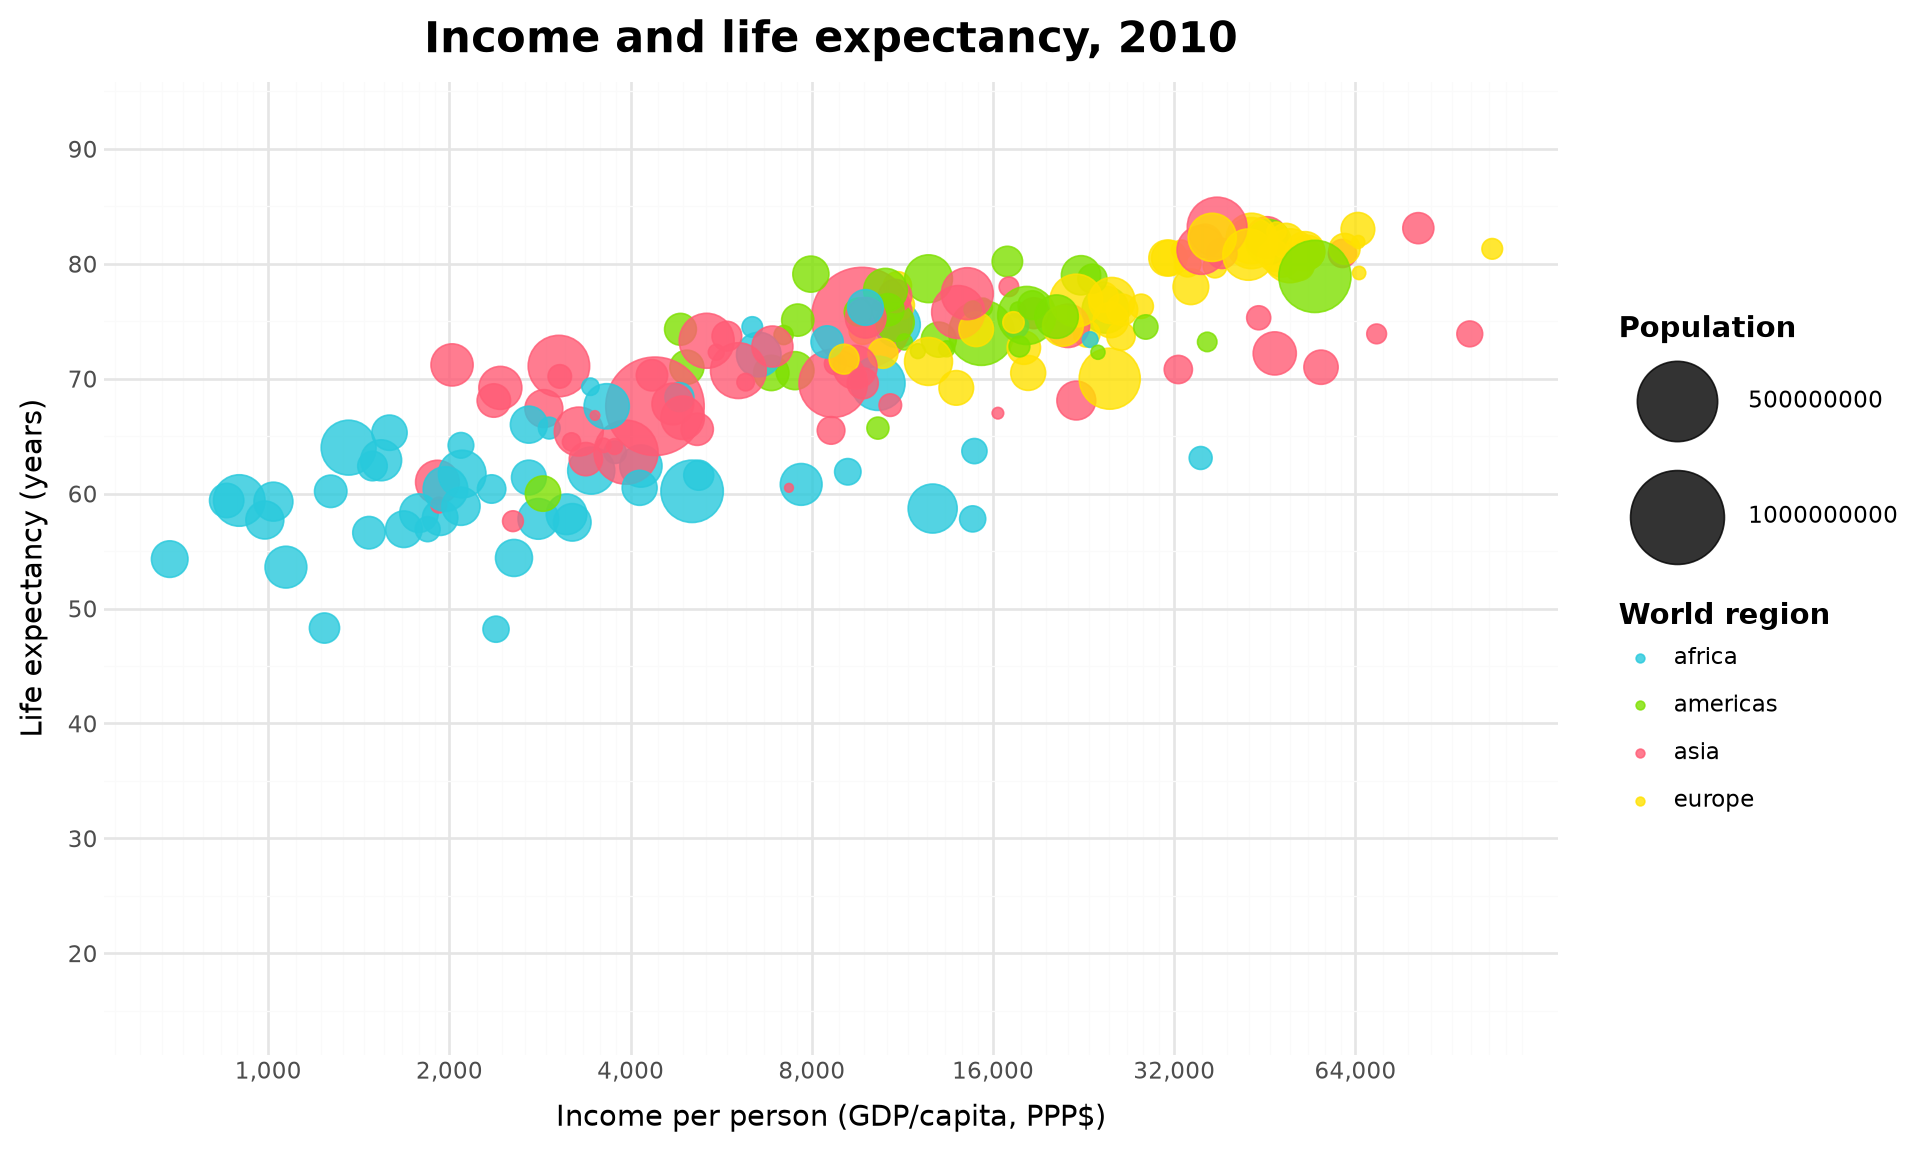

In [3]:
plot1 = (
    ggplot(q1_vis, aes(x="income", y="life_exp", color="four_regions", size="population"))
    + geom_point(alpha=0.8, stroke=0.35)
    + scale_x_log10(
        breaks=[500, 1000, 2000, 4000, 8000, 16000, 32000, 64000],
        labels=comma_format(),
    )
    + scale_y_continuous(limits=(15, 92), breaks=range(20, 91, 10))
    + scale_size_continuous(range=(1.5, 21), trans="sqrt", name="Population")
    + scale_color_manual(values=region_colors, name="World region")
    + labs(
        title="Income and life expectancy, 2010",
        x="Income per person (GDP/capita, PPP$)",
        y="Life expectancy (years)",
    )
    + base_theme
)
plot1

### Another geometry: country labels

geom_text() can use the same position, colour, and size variables. It
also uses country as the text label. This version lets a reader identify
individual countries, which can help with a small subset. The full data
set produces heavy overlap, and text size gives a weaker visual
comparison of population than bubble area.

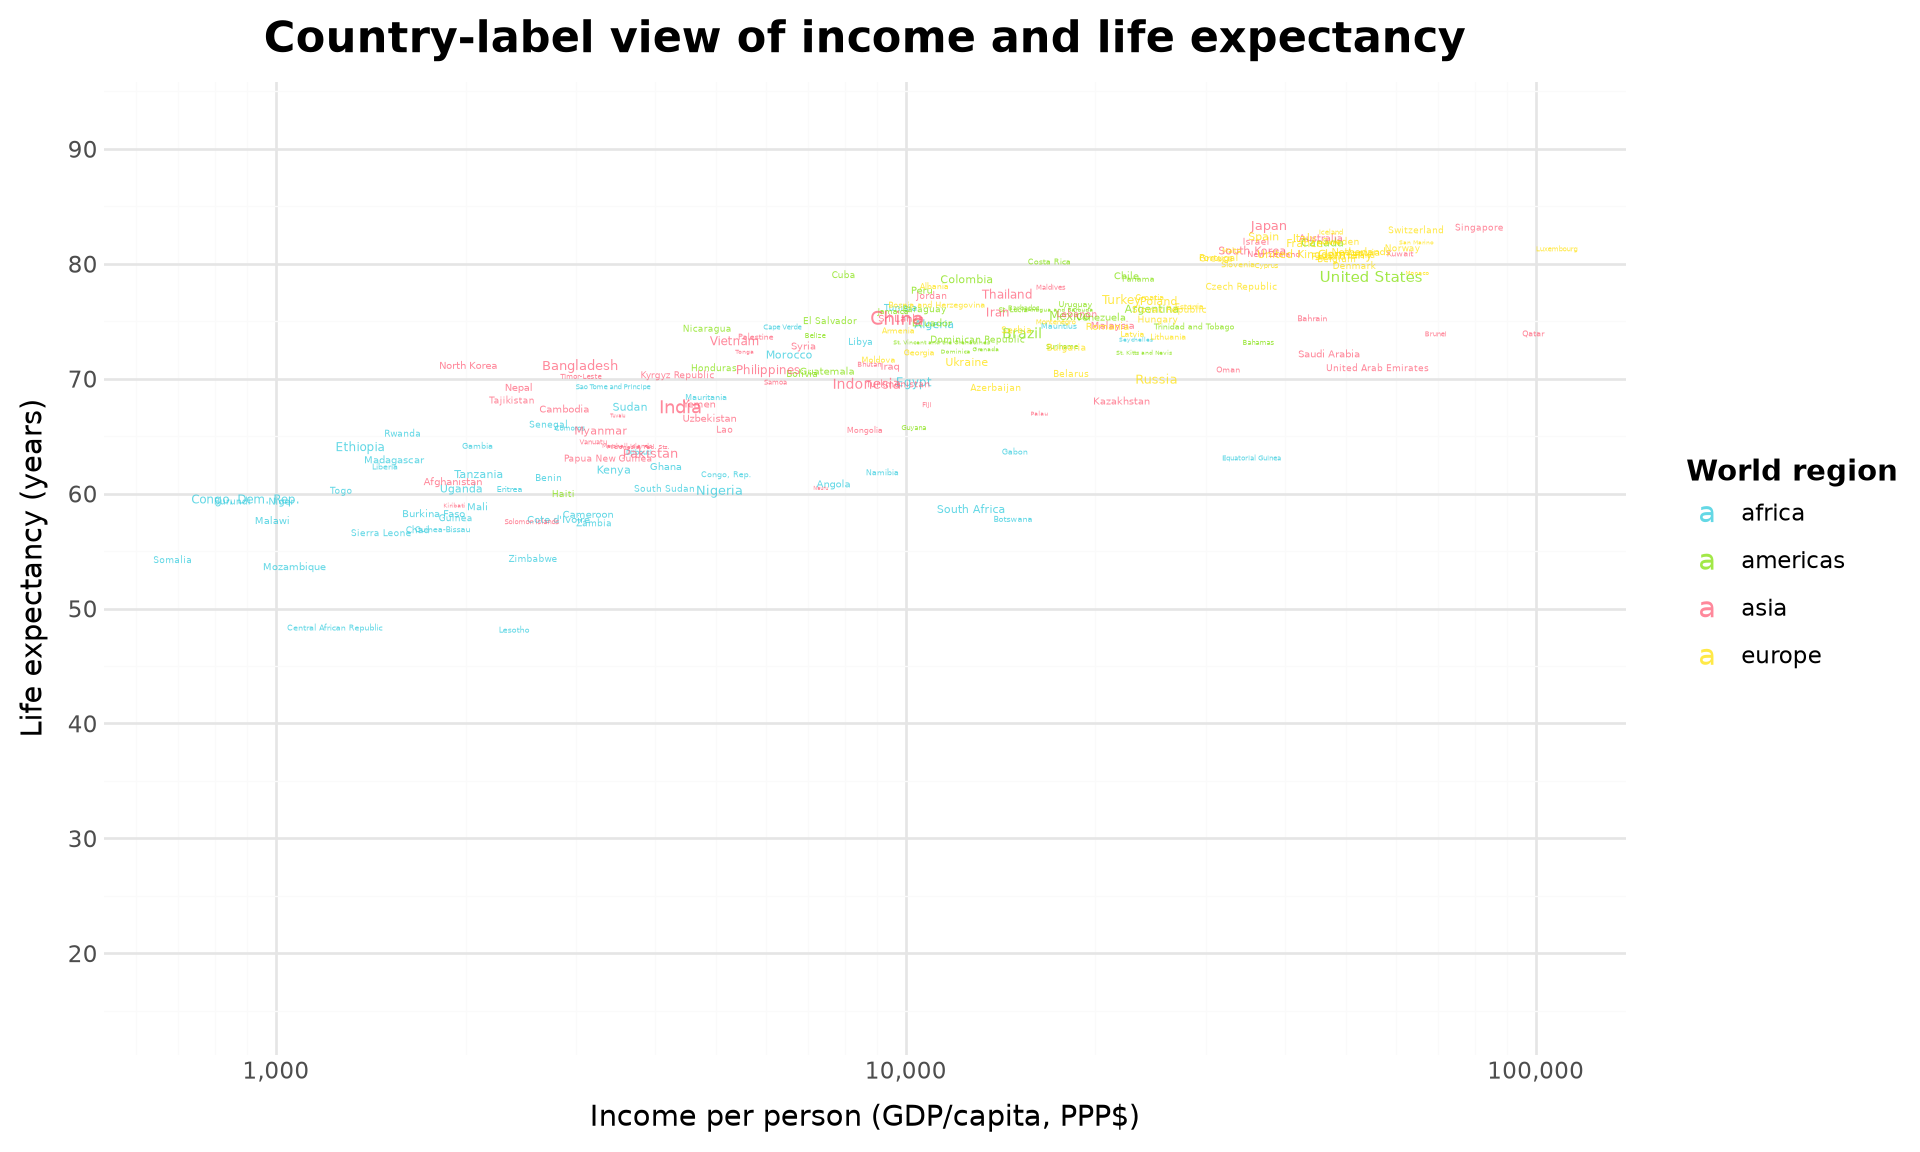

In [4]:
plot1_text = (
    ggplot(q1_vis, aes(x="income", y="life_exp", color="four_regions", size="population", label="country"))
    + geom_text(alpha=0.72)
    + scale_x_log10(labels=comma_format())
    + scale_y_continuous(limits=(15, 92), breaks=range(20, 91, 10))
    + scale_size_continuous(range=(2, 7), trans="sqrt", guide=None)
    + scale_color_manual(values=region_colors, name="World region")
    + labs(
        title="Country-label view of income and life expectancy",
        x="Income per person (GDP/capita, PPP$)",
        y="Life expectancy (years)",
    )
    + base_theme
)
plot1_text

## Plot 2: trade and energy use

The original plot uses geom_point(). Exports as a percentage of GDP
map to the horizontal position. Imports as a percentage of GDP map to
the vertical position. World region maps to point colour, and energy use
maps to point size. Both axes use linear scales.

In [5]:
import base64
from io import StringIO
embedded_q2_csv = base64.b64decode("...").decode("utf-8")
q2 = pd.read_csv(StringIO(embedded_q2_csv))
# Four values use a "k" suffix for thousands, so convert the column to numbers.
energy_text = q2["energy"].astype("string").str.strip()
energy_number = pd.to_numeric(energy_text.str.replace("k", "", regex=False), errors="coerce")
q2["energy"] = energy_number.where(~energy_text.str.endswith("k", na=False), energy_number * 1000)
q2_vis = q2.dropna(subset=["exports", "imports", "energy", "four_regions"]).copy()
q2_vis.shape

(127, 9)

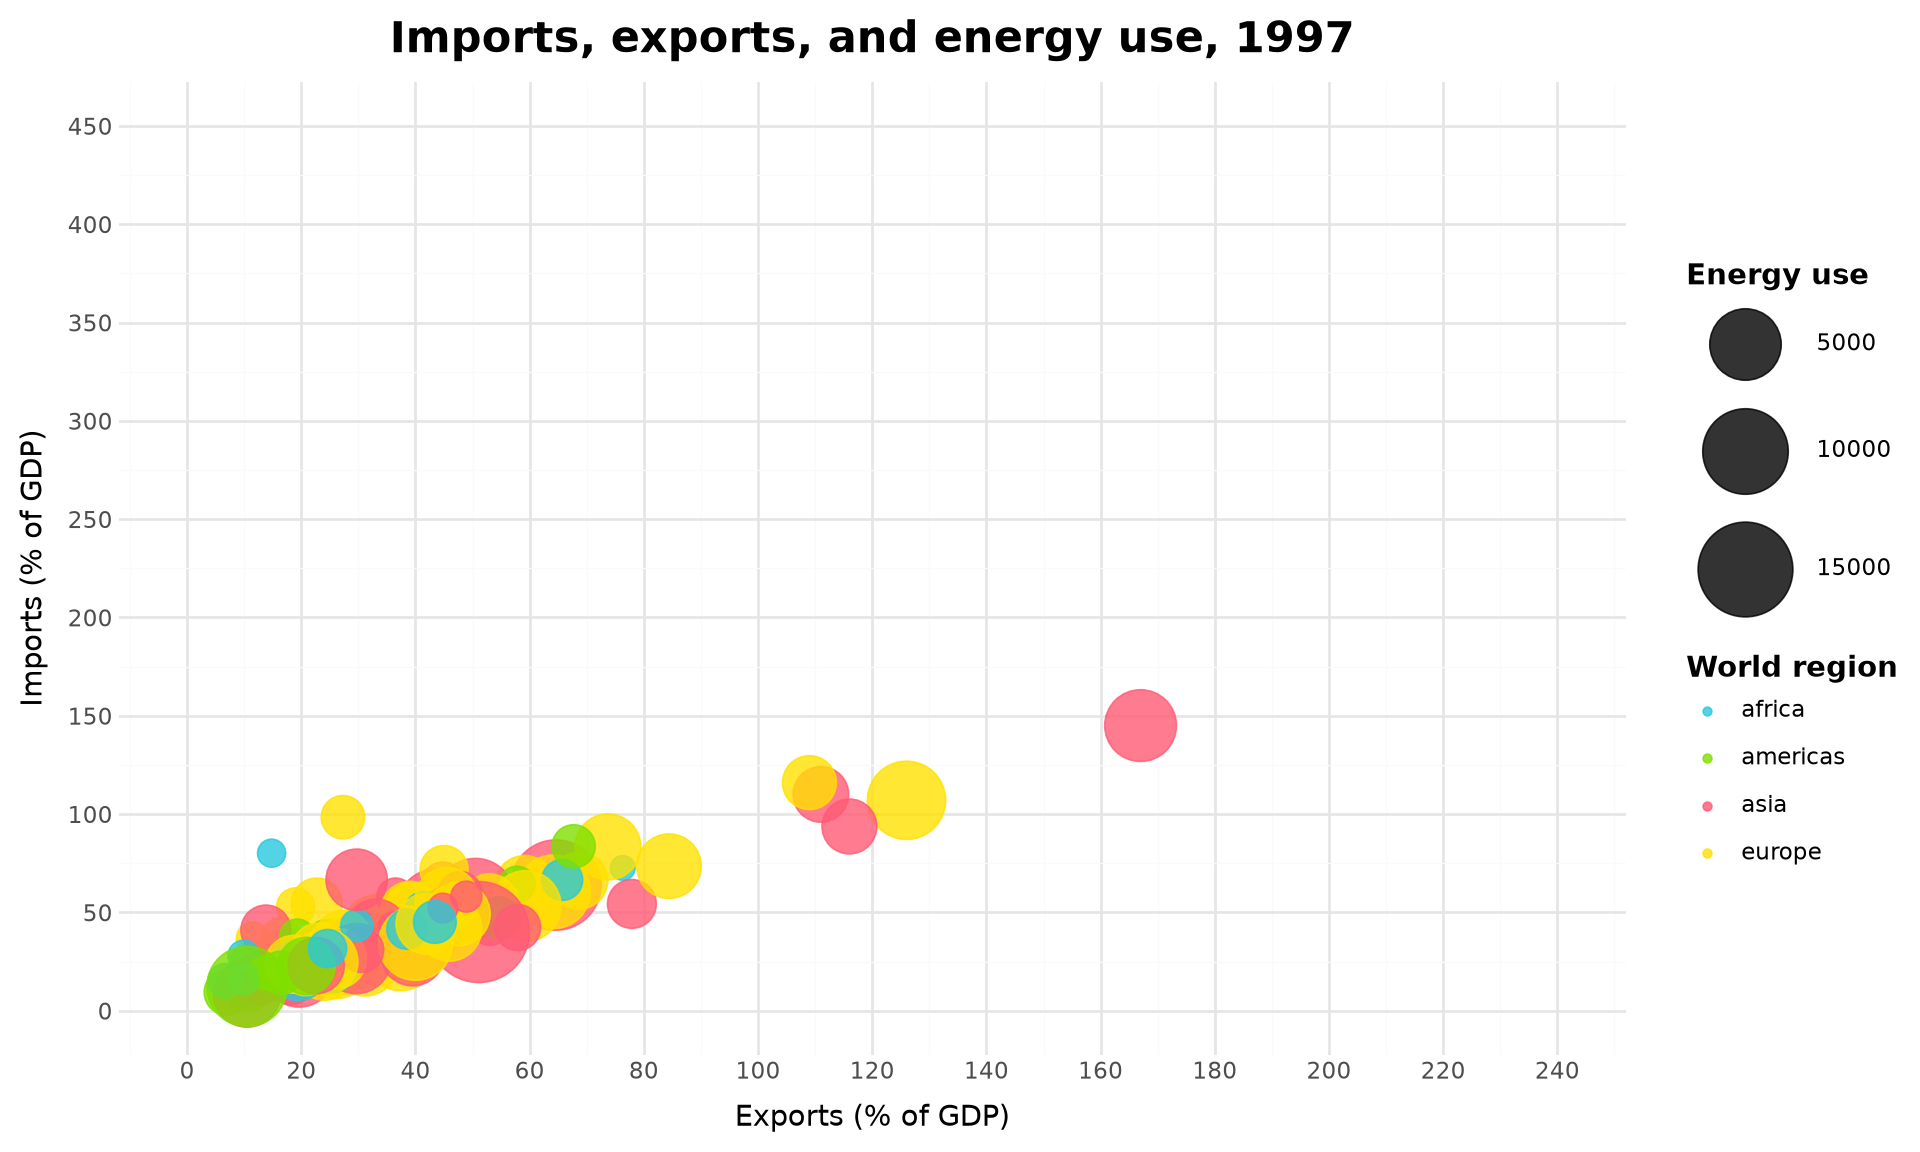

In [6]:
plot2 = (
    ggplot(q2_vis, aes(x="exports", y="imports", color="four_regions", size="energy"))
    + geom_point(alpha=0.8, stroke=0.35)
    + scale_x_continuous(limits=(0, 240), breaks=range(0, 241, 20))
    + scale_y_continuous(limits=(0, 450), breaks=range(0, 451, 50))
    + scale_size_continuous(range=(1.5, 21), trans="sqrt", name="Energy use")
    + scale_color_manual(values=region_colors, name="World region")
    + labs(
        title="Imports, exports, and energy use, 1997",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
    )
    + base_theme
)
plot2

### Another geometry: country labels

geom_text() keeps exports and imports as positions, world region as
colour, and energy use as text size. The labels reveal country
identities, but several countries occupy the same area. This geometry is
most useful after filtering the data to a small group.

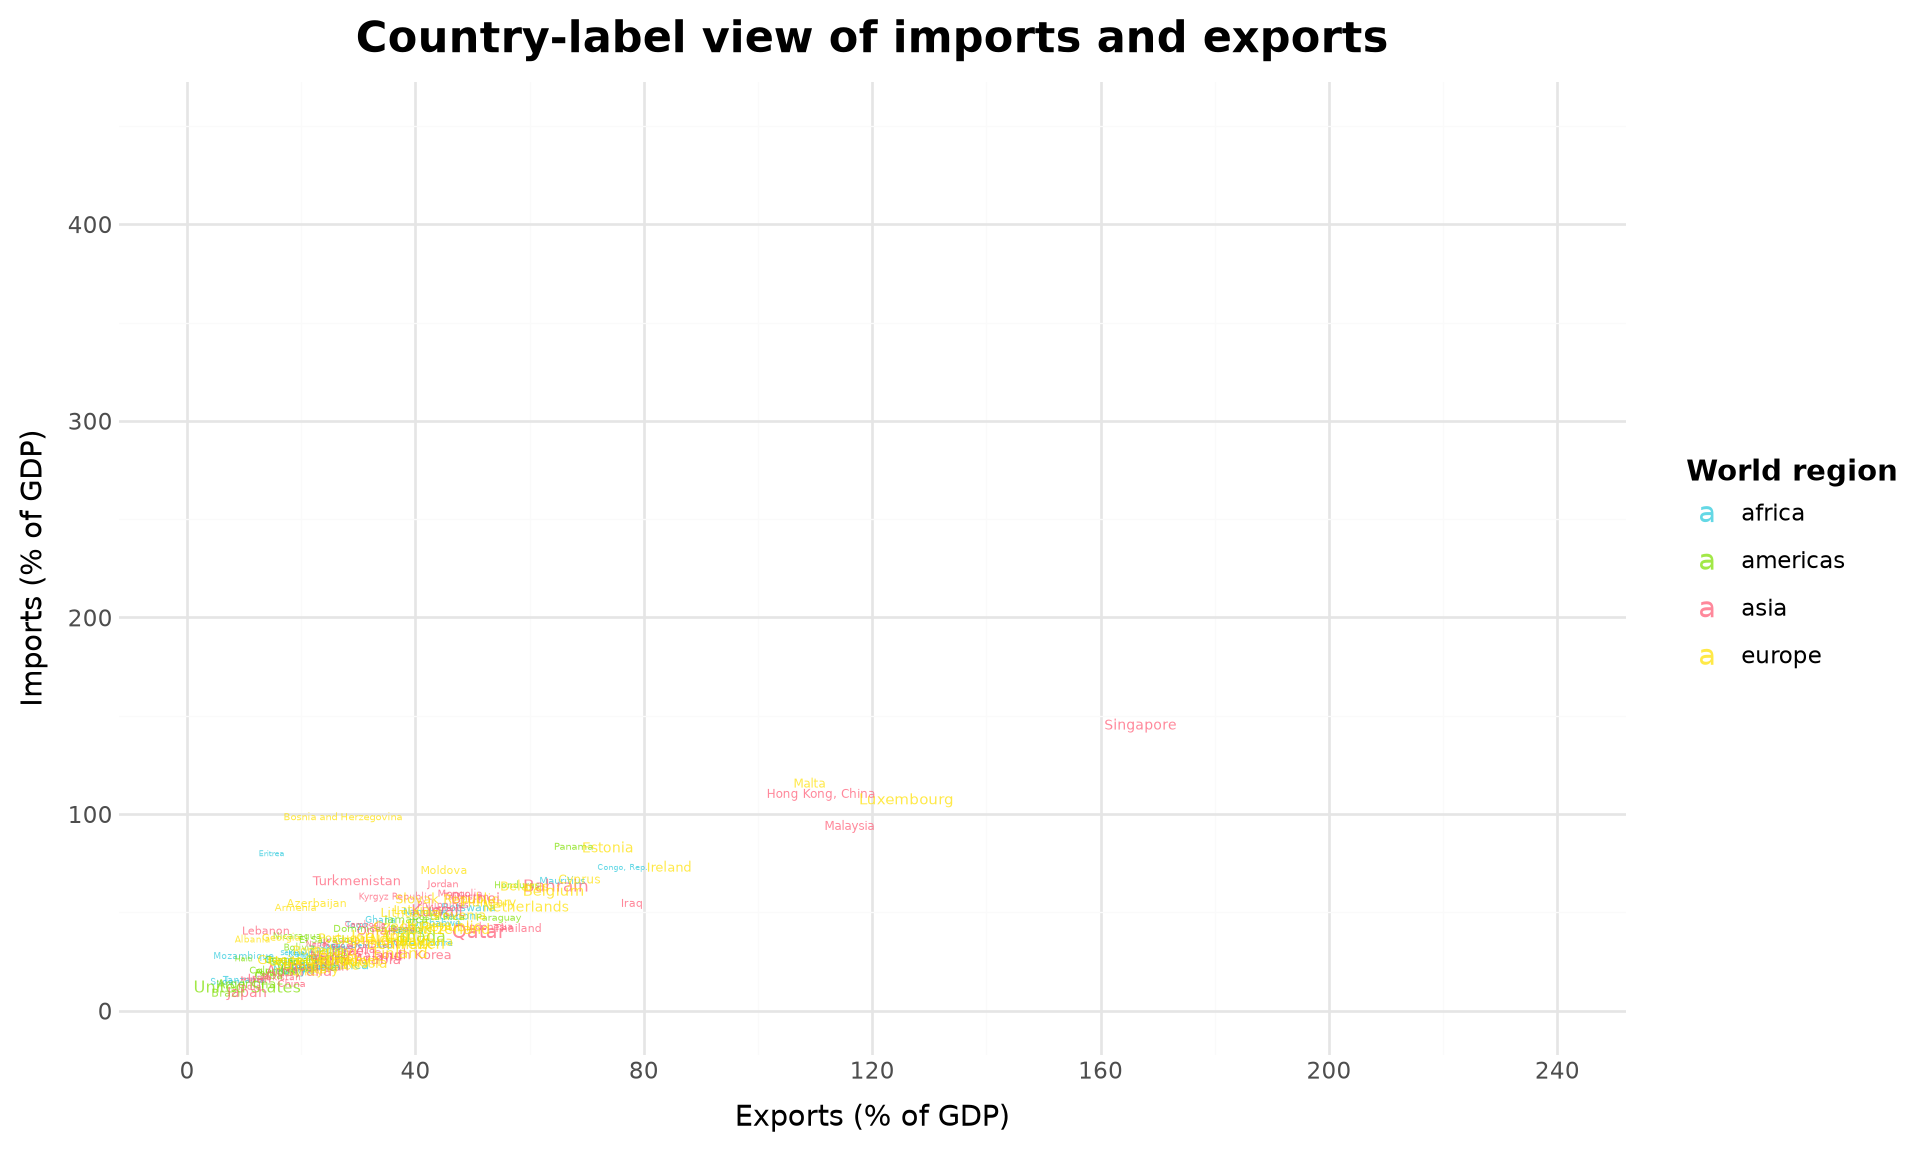

In [7]:
plot2_text = (
    ggplot(q2_vis, aes(x="exports", y="imports", color="four_regions", size="energy", label="country"))
    + geom_text(alpha=0.72)
    + scale_x_continuous(limits=(0, 240), breaks=range(0, 241, 40))
    + scale_y_continuous(limits=(0, 450), breaks=range(0, 451, 100))
    + scale_size_continuous(range=(2, 7), trans="sqrt", guide=None)
    + scale_color_manual(values=region_colors, name="World region")
    + labs(
        title="Country-label view of imports and exports",
        x="Exports (% of GDP)",
        y="Imports (% of GDP)",
    )
    + base_theme
)
plot2_text

## Plot 3: internet use and GDP per capita

The original plot uses geom_point(). The share of people using the
internet maps to the horizontal position on a linear scale. GDP per
capita maps to the vertical position on a logarithmic scale. World
region maps to point colour, and income maps to point size.

In [8]:
import base64
from io import StringIO
embedded_q3_csv = base64.b64decode("...").decode("utf-8")
q3 = pd.read_csv(StringIO(embedded_q3_csv))
q3_vis = q3.dropna(subset=["internet_users", "gdp", "income", "four_regions"]).copy()
q3_vis.shape

(181, 9)

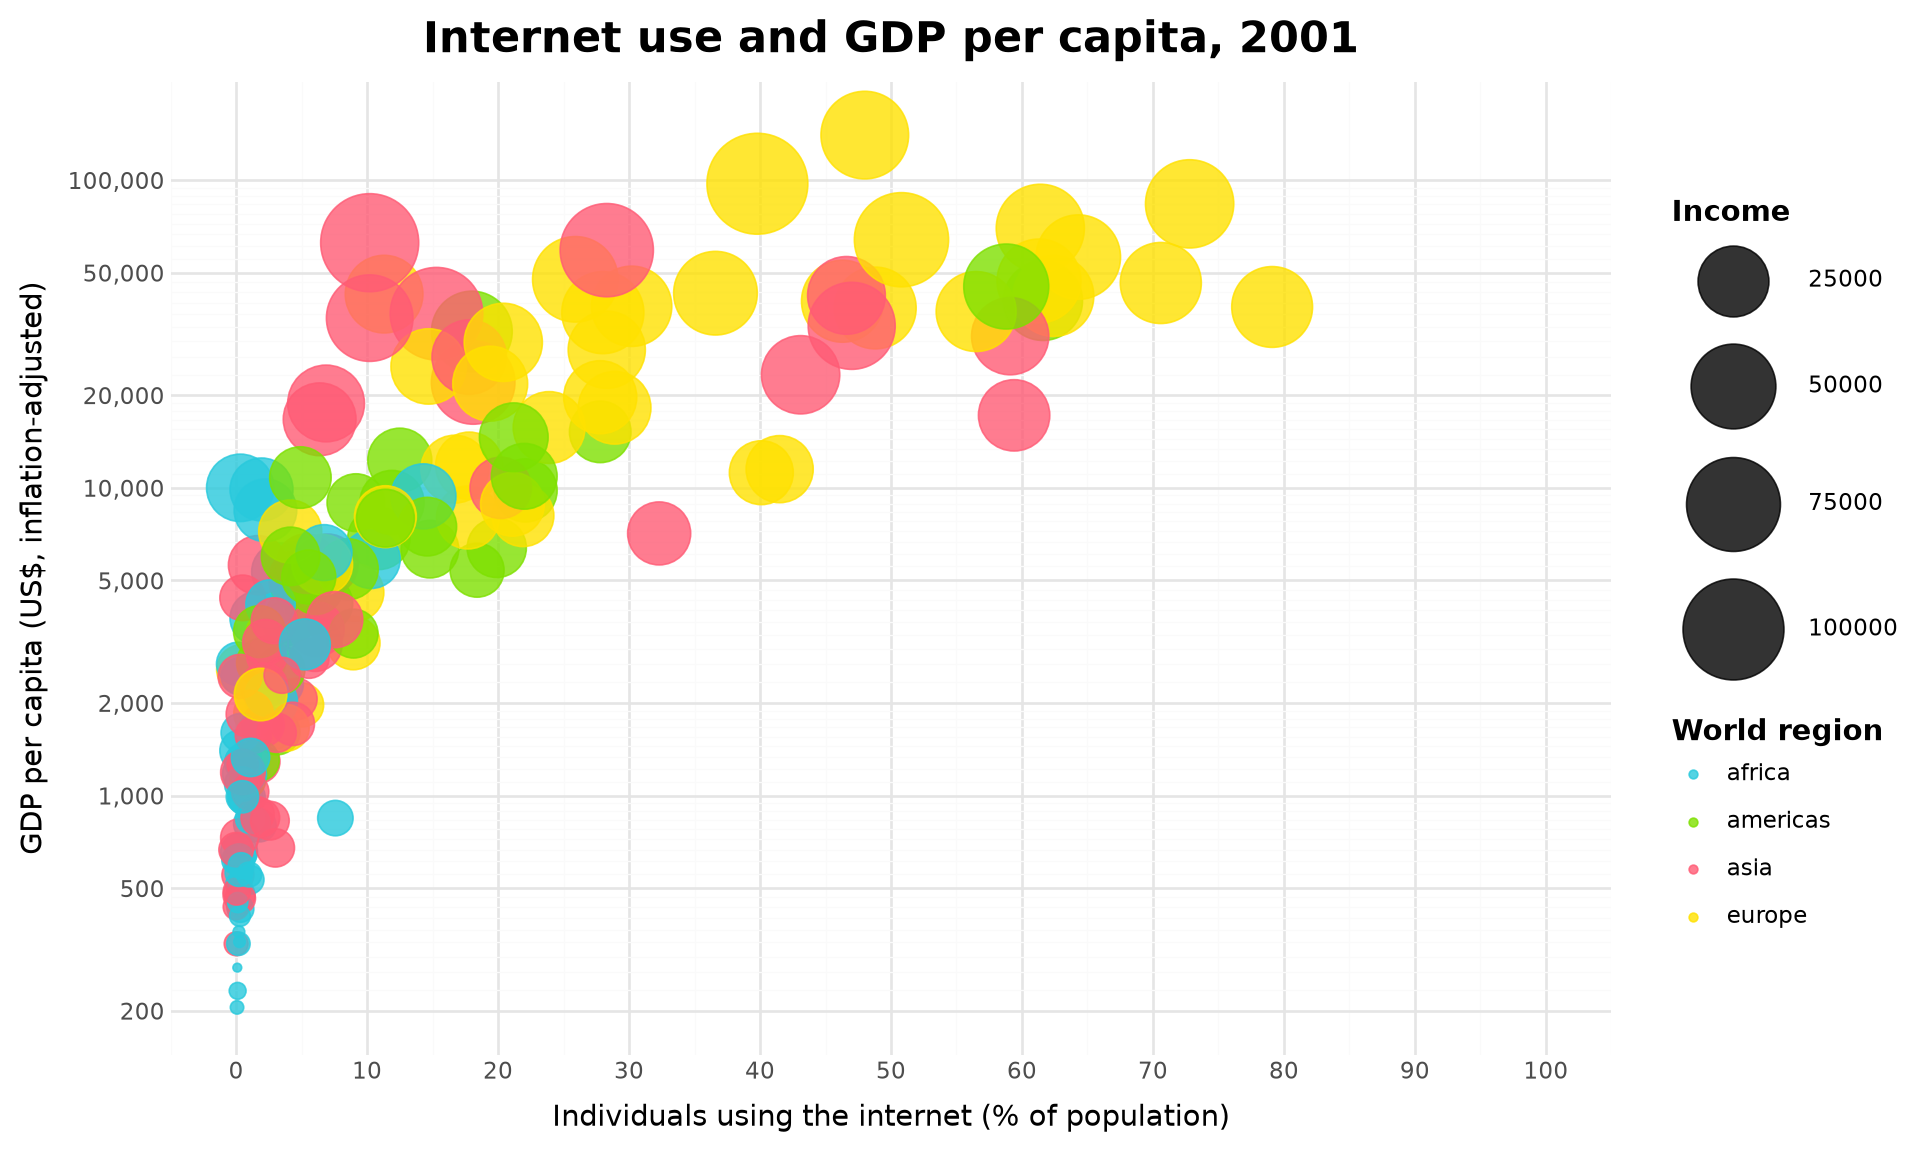

In [9]:
plot3 = (
    ggplot(q3_vis, aes(x="internet_users", y="gdp", color="four_regions", size="income"))
    + geom_point(alpha=0.8, stroke=0.35)
    + scale_x_continuous(limits=(0, 100), breaks=range(0, 101, 10))
    + scale_y_log10(
        limits=(200, 150000),
        breaks=[200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000],
        labels=comma_format(),
    )
    + scale_size_continuous(range=(1.5, 21), trans="sqrt", name="Income")
    + scale_color_manual(values=region_colors, name="World region")
    + labs(
        title="Internet use and GDP per capita, 2001",
        x="Individuals using the internet (% of population)",
        y="GDP per capita (US$, inflation-adjusted)",
    )
    + base_theme
)
plot3

### Another geometry: country labels

geom_text() supports all of the main mappings in this plot. It makes
country names available, but labels pile up among countries with low
internet use. Bubble points communicate the overall pattern more clearly
for the complete data set.

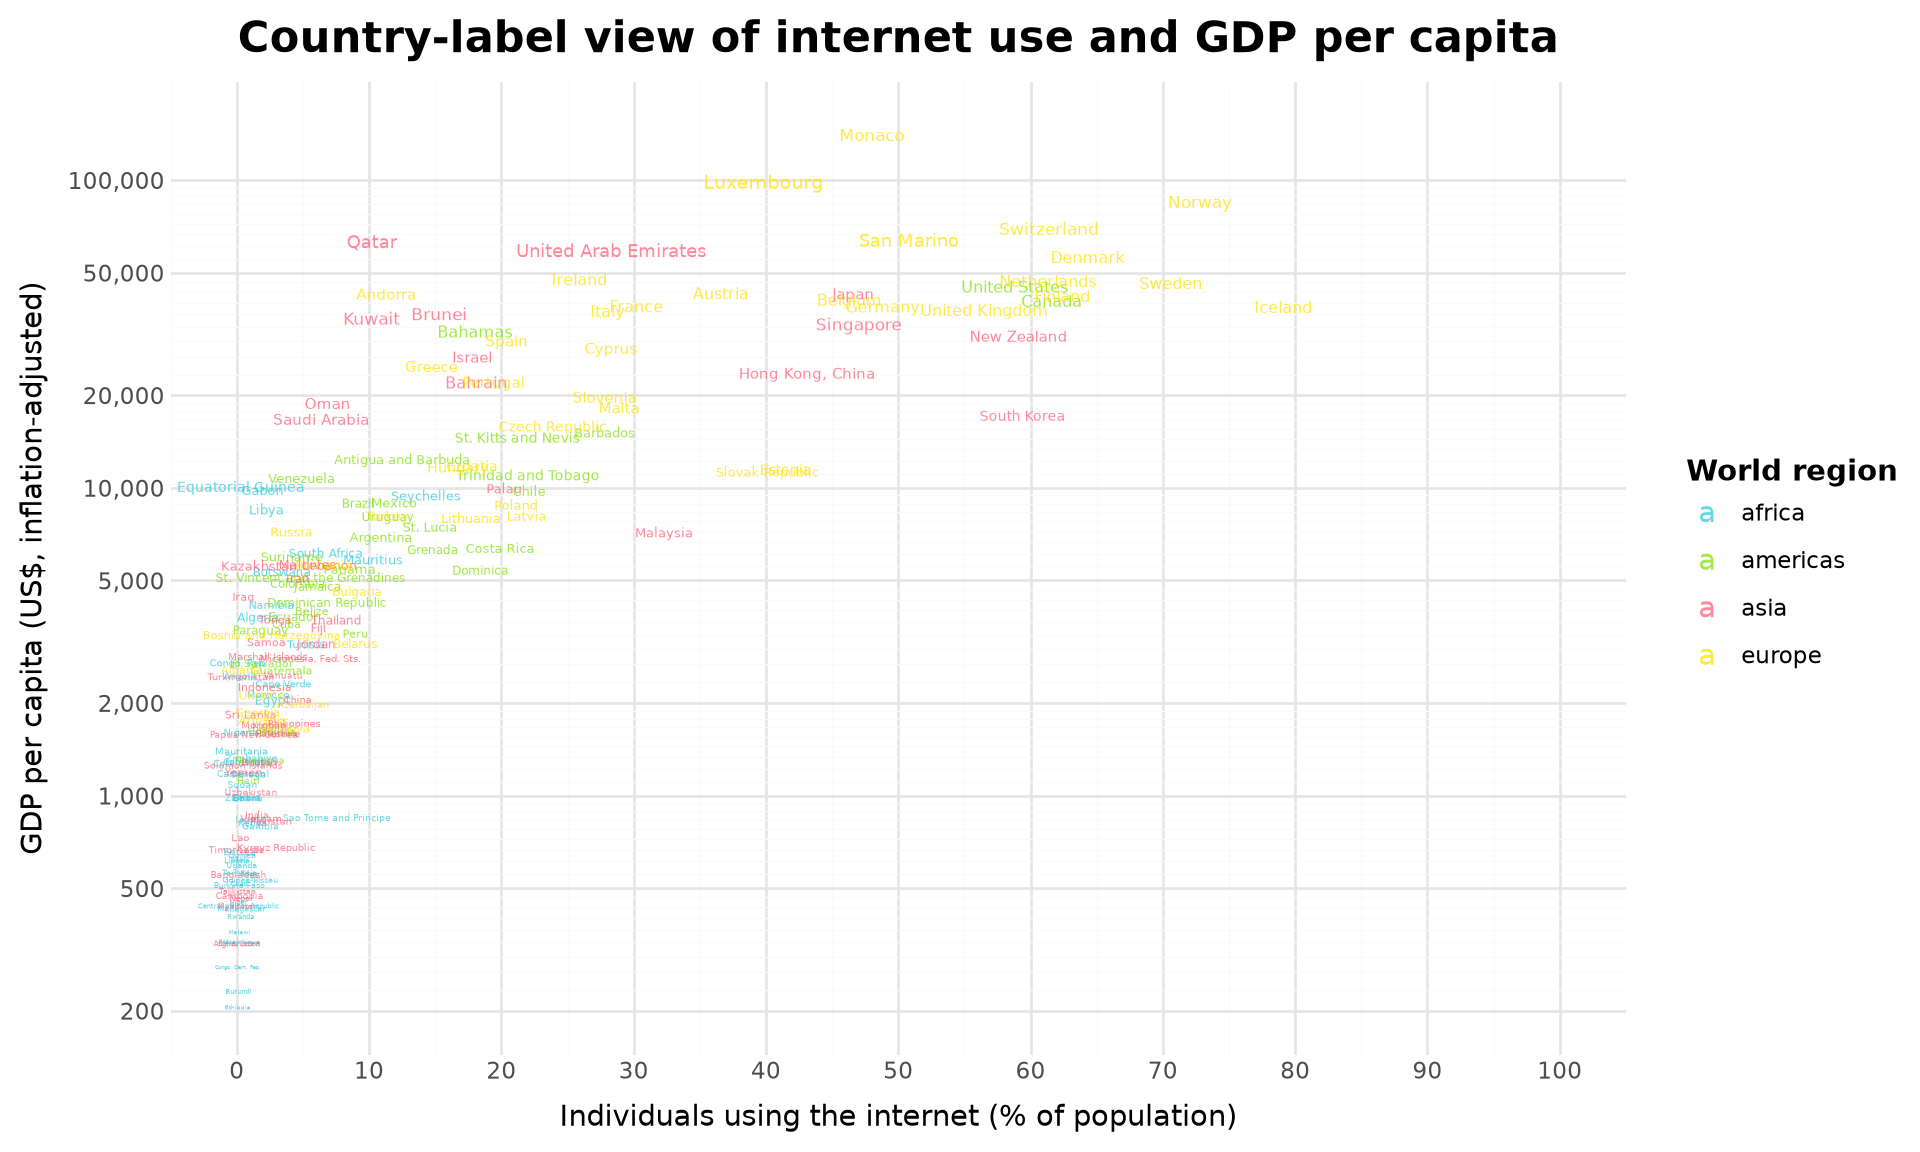

In [10]:
plot3_text = (
    ggplot(q3_vis, aes(x="internet_users", y="gdp", color="four_regions", size="income", label="country"))
    + geom_text(alpha=0.72)
    + scale_x_continuous(limits=(0, 100), breaks=range(0, 101, 10))
    + scale_y_log10(
        limits=(200, 150000),
        breaks=[200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000],
        labels=comma_format(),
    )
    + scale_size_continuous(range=(2, 7), trans="sqrt", guide=None)
    + scale_color_manual(values=region_colors, name="World region")
    + labs(
        title="Country-label view of internet use and GDP per capita",
        x="Individuals using the internet (% of population)",
        y="GDP per capita (US$, inflation-adjusted)",
    )
    + base_theme
)
plot3_text